# Process Performance Map

Visualizes model prediction performance overlaid on a process map.

- **Start node**: How many cases start with each activity
- **Node color**: Overall accuracy when predicting from this activity
- **Edge color**: Accuracy for this specific transition (green = high, red = low)
- **Edge label**: correct/total predictions

In [1]:
# Setup
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability.visualization.process_performance_map import ProcessPerformanceMap

print(f"Dataset: {CONFIG.dataset_name}")

Dataset: Helpdesk


In [2]:
# Load model and data

model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Loaded 6077 samples
Available cases: 916


In [3]:
# Collect predictions
ppm = ProcessPerformanceMap(
    model=model,
    test_dataset=test_dataset,
    eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
    device=device
)

ppm.collect_predictions(show_progress=True)


Collected 4245 predictions
Found 44 unique transitions


In [4]:
# --- Overall accuracy summary ---
from collections import Counter, defaultdict
import pandas as pd

preds = ppm.predictions
n_total = len(preds)
n_correct = sum(1 for p in preds if p.correct)
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

# Per prefix-length
by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for p in preds:
    by_plen[p.prefix_length]['total'] += 1
    by_plen[p.prefix_length]['correct'] += int(p.correct)
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

# Mean confidence (softmax argmax prob at the predicted class)
mean_conf = sum(p.confidence for p in preds) / n_total if n_total else 0.0
print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 3168/4245 = 0.7463 (74.63%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1      491    916  0.536026
             2      597    916  0.651747
             3      760    916  0.829694
             4      793    878  0.903189
             5      313    357  0.876751
             6      121    148  0.817568
             7       54     66  0.818182
             8       23     29  0.793103
             9       10     12  0.833333
            10        3      4  0.750000
            11        2      2  1.000000
            12        1      1  1.000000

Mean top-1 confidence: 69.07%


In [5]:
# Create activity name mapping
label_dict = ppm.get_activity_label_dict()
activity_name_map = {str(idx): name for name, idx in label_dict.items()}

print("Activity mapping:")
for idx_str in sorted(activity_name_map.keys(), key=lambda x: int(x) if x.isdigit() else 0):
    print(f"  {idx_str}: {activity_name_map[idx_str]}")

Activity mapping:
  1: Assign seriousness
  2: Closed
  3: Create SW anomaly
  4: DUPLICATE
  5: EOS
  6: INVALID
  7: Insert ticket
  8: RESOLVED
  9: Require upgrade
  10: Resolve SW anomaly
  11: Resolve ticket
  12: Schedule intervention
  13: Take in charge ticket
  14: VERIFIED
  15: Wait


## Process Map

Filtered out 0 rare activities (< 0 occurrences)
Filtered out 0 rare directly-follows edges (< 0 occurrences)
Remaining: 14 activities, 45 edges


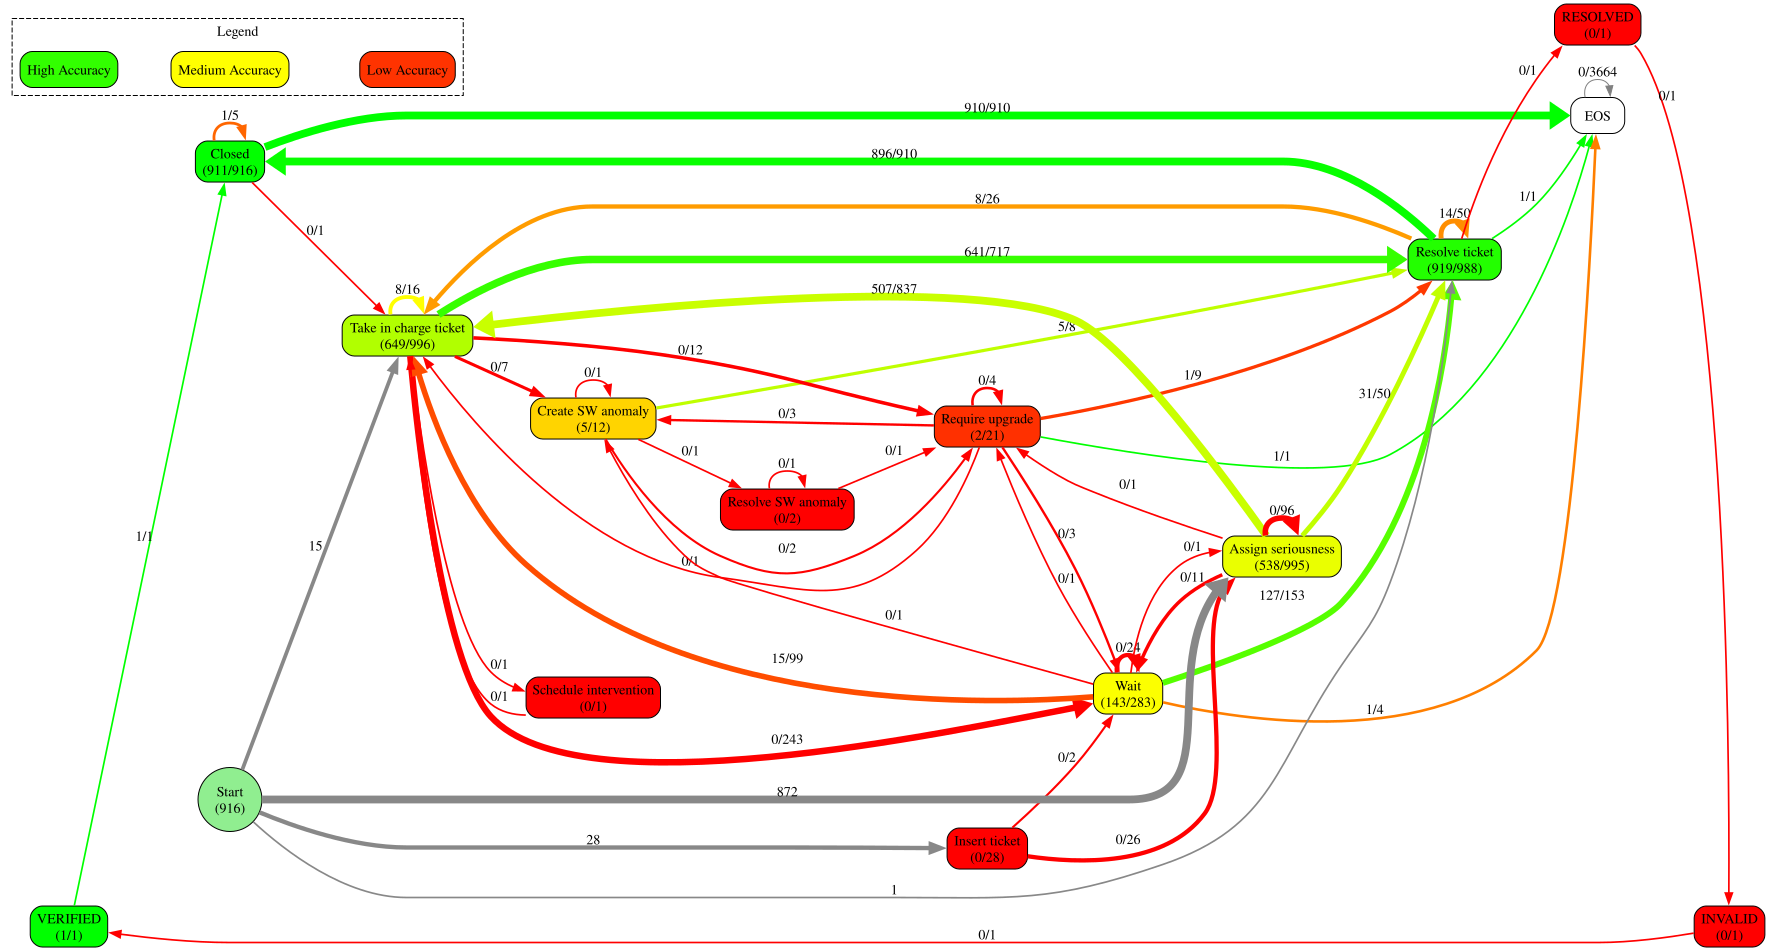

In [6]:
# ============================================
# FILTERING THRESHOLDS
# ============================================
MIN_EDGE_COUNT = 0       # hide directly-follows edges seen fewer times
MIN_ACTIVITY_COUNT = 0  # hide activities whose total occurrences fall below this

# --- Pre-filter the DFG based on thresholds ---
# Compute per-activity frequency from the DFG
if ppm.dfg is None:
    ppm.mine_dfg()

activity_freq = {}
for (src_act, tgt_act), cnt in ppm.dfg.items():
    activity_freq[src_act] = activity_freq.get(src_act, 0) + cnt
    activity_freq[tgt_act] = activity_freq.get(tgt_act, 0) + cnt

keep_activities = {a for a, c in activity_freq.items() if c >= MIN_ACTIVITY_COUNT}

# Backup original DFG so we can restore it
_original_dfg = dict(ppm.dfg)
ppm.dfg = {
    (s, t): c for (s, t), c in _original_dfg.items()
    if s in keep_activities and t in keep_activities and c >= MIN_EDGE_COUNT
}

n_removed_acts = len(activity_freq) - len(keep_activities)
n_removed_edges = len(_original_dfg) - len(ppm.dfg)
print(f'Filtered out {n_removed_acts} rare activities '
      f'(< {MIN_ACTIVITY_COUNT} occurrences)')
print(f'Filtered out {n_removed_edges} rare directly-follows edges '
      f'(< {MIN_EDGE_COUNT} occurrences)')
print(f'Remaining: {len(keep_activities)} activities, {len(ppm.dfg)} edges')

# Generate process map with filtered DFG
dot = ppm.visualize(
    min_edge_count=MIN_EDGE_COUNT,
    show_counts=True,
    activity_name_map=activity_name_map,
    show_start_node=True,
)

# Restore for any downstream analysis
ppm.dfg = _original_dfg

dot

## Interactive Explorer

In [ ]:
# Interactive exploration
explorer = ppm.create_interactive_explorer(activity_name_map=activity_name_map)
explorer.show()